# 02 — Growth, commercial value and operational risk
**Business questions:** What drives GMV? Which categories, sellers and states matter? Where do scale and poor experience overlap?

**Contents:** executive KPIs; growth bridge; category portfolio; seller and geographic priorities; payments; delivery/reviews; concentration; SQL parity. All sections use the population contract in `docs/metric_dictionary.md`.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import numpy as np
from IPython.display import display, Markdown, Image
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
pd.set_option('display.max_columns', 18)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
def table(name): return pd.read_csv(ROOT / 'output' / (name + '.csv'))
def chart(name): display(Image(filename=str(ROOT / 'images' / name), width=950))
def decision(evidence, interpretation, action, kpi):
    display(Markdown(f'**What the data shows:** {evidence}\n\n**Business interpretation:** {interpretation}\n\n**Recommended action:** {action}\n\n**KPI to monitor:** {kpi}'))

In [2]:
from src.pipeline import business
analytics=business(ROOT)
display(analytics['populations'])

,population,orders
0,commercial_eligible,96478
1,delivery_eligible,96282
2,review_eligible,95832


## Executive KPIs
Every result below includes its definition, unit and eligible population. Review metrics exclude missing reviews; delay rates exclude unusable delivery records. Customer counts never use the order-specific customer ID.

In [3]:
display(analytics['kpis'])
k=analytics['kpis'].set_index('metric').value
decision(f"Delivered GMV is BRL {k['GMV']:,.2f}; AOV is BRL {k['AOV']:,.2f}.",
         'GMV describes merchandise sold, not marketplace revenue or profit.',
         'Use the same reconciled definitions for management reporting.',
         'GMV, orders, customers, AOV and population coverage.')

,metric,value,unit,definition,population,population_orders
0,GMV,"13,221,498.1100",BRL,Delivered item merchandise; excludes freight,commercial,96478
1,Payment value,"15,422,461.7700",BRL,Recorded payments on commercial orders; missin...,commercial,96478
2,Orders,"96,478.0000",count,Delivered orders with items and a purchase tim...,commercial,96478
3,Units sold,"110,197.0000",count,Item rows on commercial orders,commercial,96478
4,Customers,"93,358.0000",count,Distinct customer_unique_id on commercial orders,commercial,96478
5,AOV,137.0416,BRL,GMV / commercial orders,commercial,96478
6,Average item value,119.9806,BRL,GMV / units,commercial,96478
7,Items per order,1.1422,decimal,Units / commercial orders,commercial,96478
8,Freight / merchandise,0.1663,percent,"Freight divided by merchandise, not total payment",commercial,96478
9,Repeat customer rate,0.0300,percent,Customers with >1 eligible orders / customers ...,commercial,96478


**What the data shows:** Delivered GMV is BRL 13,221,498.11; AOV is BRL 137.04.

**Business interpretation:** GMV describes merchandise sold, not marketplace revenue or profit.

**Recommended action:** Use the same reconciled definitions for management reporting.

**KPI to monitor:** GMV, orders, customers, AOV and population coverage.

## Why did GMV change?
GMV = customers × purchase frequency × AOV. The exact sequential bridge attributes customer change first, frequency second, AOV third; its components reconcile to monthly GMV change. It is not a causal marketing model. Boundary periods are flagged and seasonality cannot be established from this short, rapidly growing sample alone.

,purchase_month,gmv,orders,customers,units,aov,items_per_order,orders_per_customer,gmv_per_customer,...,customers_mom,aov_mom,items_per_order_mom,orders_per_customer_mom,gmv_per_customer_mom,customer_effect,frequency_effect,aov_effect,boundary_month
12,2017-09,"607,399.6700",4150,4083,"4,737.0000",146.3614,1.1414,1.0164,148.7631,...,-0.0075,0.1064,-0.0023,-0.0027,0.1033,"-4,179.7984","-1,508.7509","58,388.5193",False
13,2017-10,"648,247.6500",4478,4417,"5,214.0000",144.7628,1.1644,1.0138,146.7620,...,0.0818,-0.0109,0.0201,-0.0026,-0.0135,"49,686.8699","-1,680.3418","-7,158.5481",False
14,2017-11,"987,765.3700",7289,7183,"8,475.0000",135.5145,1.1627,1.0148,137.5143,...,0.6262,-0.0639,-0.0014,0.0009,-0.0630,"405,943.6269",984.4982,"-67,410.4051",False
15,2017-12,"726,033.1900",5513,5450,"6,187.0000",131.6948,1.1223,1.0116,133.2171,...,-0.2413,-0.0282,-0.0348,-0.0032,-0.0312,"-238,312.3188","-2,361.4769","-21,058.3843",False
16,2018-01,"924,645.0000",7069,6974,"8,037.0000",130.8028,1.1369,1.0136,132.5846,...,0.2796,-0.0068,0.0131,0.0020,-0.0047,"203,022.8590","1,894.1814","-6,305.2304",False
17,2018-02,"826,437.1300",6555,6400,"7,518.0000",126.0774,1.1469,1.0242,129.1308,...,-0.0823,-0.0361,0.0088,0.0105,-0.0260,"-76,103.5604","8,870.9207","-30,975.2303",False
18,2018-03,"953,356.2500",7003,6914,"8,017.0000",136.1354,1.1448,1.0129,137.8878,...,0.0803,0.0798,-0.0018,-0.0111,0.0678,"66,373.2320","-9,890.5723","70,436.4603",False
19,2018-04,"973,534.0900",6798,6744,"7,827.0000",143.2089,1.1514,1.0080,144.3556,...,-0.0246,0.0520,0.0057,-0.0048,0.0469,"-23,440.9260","-4,466.8323","48,085.5983",False
20,2018-05,"977,544.6900",6749,6693,"7,810.0000",144.8429,1.1572,1.0084,146.0548,...,-0.0076,0.0114,0.0051,0.0004,0.0118,"-7,362.1350",344.8990,"11,027.8360",False
21,2018-06,"856,077.8600",6099,6061,"7,010.0000",140.3636,1.1494,1.0063,141.2437,...,-0.0944,-0.0309,-0.0068,-0.0021,-0.0329,"-92,306.6254","-1,841.2555","-27,318.9491",False


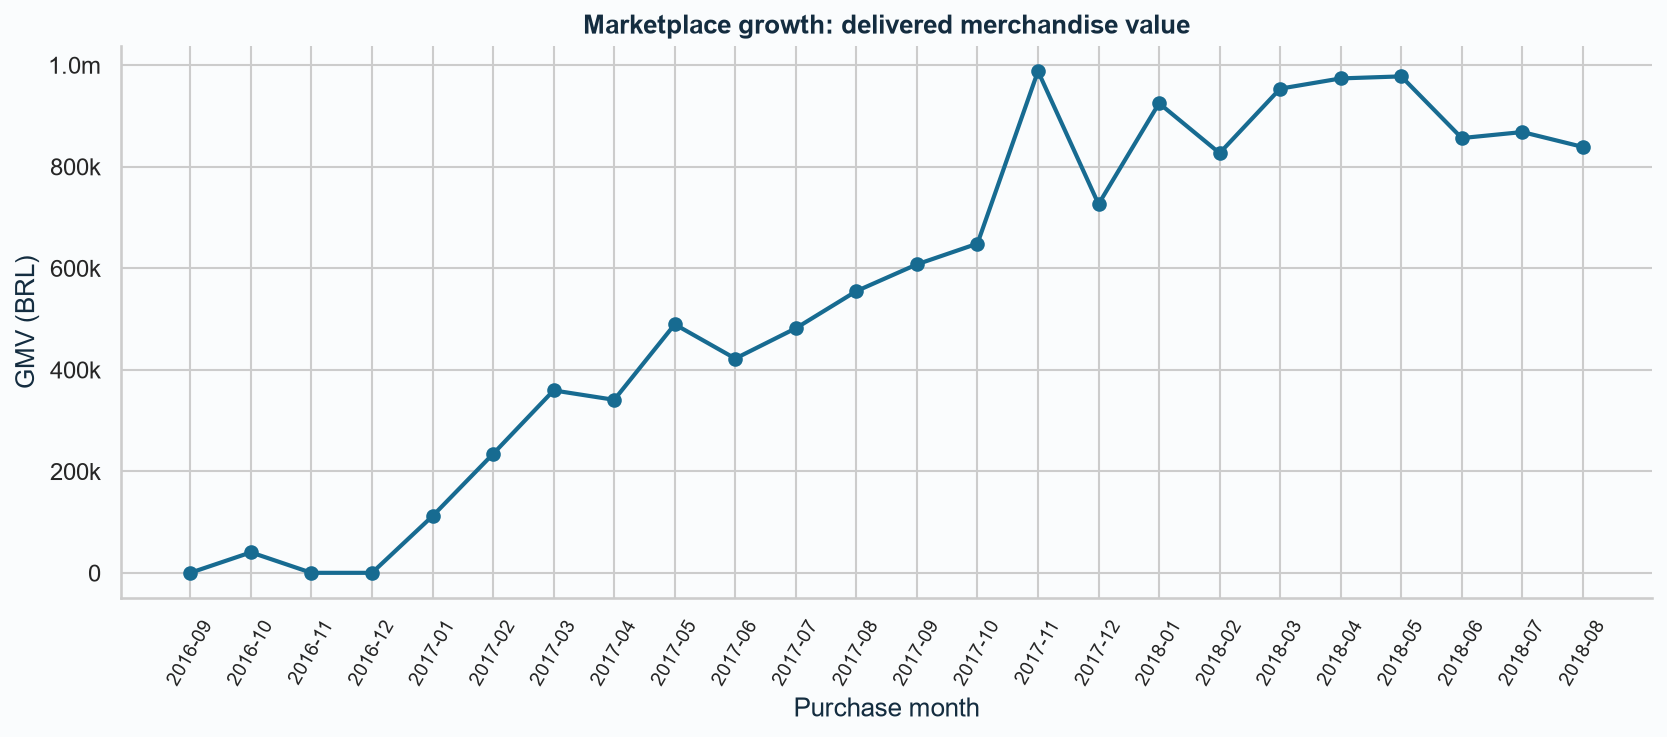

**What the data shows:** Among non-boundary months with at least 100 orders, 2017-12 had the weakest relative GMV change: -26.5%.

**Business interpretation:** The exact BRL bridge is customers -238,312, frequency -2,361, AOV -21,058.

**Recommended action:** Investigate basket mix and customer volume before selecting a growth intervention.

**KPI to monitor:** Customers, orders/customer, AOV and comparable-period GMV.

In [4]:
m=analytics['monthly']
display(m.tail(12))
chart('monthly_growth.png')
valid=m[~m.boundary_month & m.gmv_mom.notna() & m.orders.ge(100)]
r=valid.sort_values('gmv_mom').iloc[0]
decision(f"Among non-boundary months with at least 100 orders, {r.purchase_month} had the weakest relative GMV change: {r.gmv_mom:.1%}.",
         f"The exact BRL bridge is customers {r.customer_effect:,.0f}, frequency {r.frequency_effect:,.0f}, AOV {r.aov_effect:,.0f}.",
         'Investigate basket mix and customer volume before selecting a growth intervention.',
         'Customers, orders/customer, AOV and comparable-period GMV.')

## Category portfolio: value and experience together
Item GMV is additive. Category orders are distinct orders containing a category and are not additive across categories. Priority classifications use top-quartile GMV, at least 50 eligible delivery/review observations, and a Wilson lower bound above the marketplace late-rate baseline. Growth compares equal three-month windows, excluding eligible-window boundaries.

In [5]:
display(analytics['categories'].head(15))
priority=analytics['categories'].query("priority_group == 'Improvement priority'").sort_values('excess_late_orders',ascending=False)
display(priority[['category','gmv','orders','late_delivery_rate','late_ci_low','late_ci_high','low_review_rate','excess_late_orders']])
decision(f"{len(priority)} categories meet the high-value, elevated-late-rate priority rules.",
         'A large issue count can reflect commercial scale; confidence and rates add context.',
         'Review the leading priority categories with operations and their major sellers.',
         'Late rate, eligible order count, low-review rate and GMV exposure.')

,category,gmv,units,orders,customers,delivery_orders,late_orders,average_delivery_days,reviewed_orders,...,late_rate_baseline,excess_late_orders,gmv_on_late_orders,high_commercial_value,weak_experience,growth_rate,priority_group,priority_rank,cumulative_gmv_share
0,health_beauty,"1,233,131.7200",9465,8647,8498,8629,649,12.0821,8601,...,0.0678,63.5881,"94,273.3900",True,True,0.1718,Improvement priority,1.0000,0.0933
1,watches_gifts,"1,166,176.9800",5859,5495,5421,5482,406,12.8156,5454,...,0.0678,34.0881,"91,298.0500",True,False,0.2226,Strong commercial performer,4.0000,0.1815
2,bed_bath_table,"1,023,434.7600",10953,9272,9008,9250,689,13.0034,9177,...,0.0678,61.4580,"79,235.1000",True,True,-0.0151,Improvement priority,2.0000,0.2589
3,sports_leisure,"954,852.5500",8431,7530,7341,7517,495,12.2495,7486,...,0.0678,0.0000,"70,453.2600",True,False,-0.2876,Strong commercial performer,22.0000,0.3311
4,computers_accessories,"888,724.6100",7644,6530,6405,6517,417,13.1873,6499,...,0.0678,0.0000,"61,459.3200",True,False,-0.4488,Strong commercial performer,22.0000,0.3983
5,furniture_decor,"711,927.6900",8160,6307,6178,6288,449,13.0892,6260,...,0.0678,22.4071,"58,515.9400",True,False,-0.0302,Strong commercial performer,5.0000,0.4522
6,housewares,"615,628.6900",6795,5743,5681,5731,308,11.0970,5709,...,0.0678,0.0000,"38,465.3100",True,False,0.5865,Strong commercial performer,22.0000,0.4987
7,cool_stuff,"610,204.1000",3718,3559,3543,3555,210,12.3880,3531,...,0.0678,0.0000,"39,269.4800",True,False,-0.3136,Strong commercial performer,22.0000,0.5449
8,auto,"578,966.6500",4140,3810,3769,3792,277,12.3511,3792,...,0.0678,19.7417,"66,522.3300",True,False,-0.0288,Strong commercial performer,7.0000,0.5887
9,toys,"471,286.4800",4030,3804,3763,3795,243,11.7449,3774,...,0.0678,0.0000,"31,606.1000",True,False,0.1578,Strong commercial performer,22.0000,0.6243


,category,gmv,orders,late_delivery_rate,late_ci_low,late_ci_high,low_review_rate,excess_late_orders
0,health_beauty,"1,233,131.7200",8647,0.0752,0.0698,0.0810,0.1145,63.5881
2,bed_bath_table,"1,023,434.7600",9272,0.0745,0.0693,0.0800,0.1603,61.4580
11,baby,"400,421.8400",2809,0.0806,0.0711,0.0912,0.1428,35.7021


**What the data shows:** 3 categories meet the high-value, elevated-late-rate priority rules.

**Business interpretation:** A large issue count can reflect commercial scale; confidence and rates add context.

**Recommended action:** Review the leading priority categories with operations and their major sellers.

**KPI to monitor:** Late rate, eligible order count, low-review rate and GMV exposure.

## Seller intelligence and volume × rate × business impact
Bubble size encodes item GMV; rate denominators use one order/seller pair. Order-level delivery does not establish which seller caused a multi-seller delay. Small samples are excluded from priority ranking.

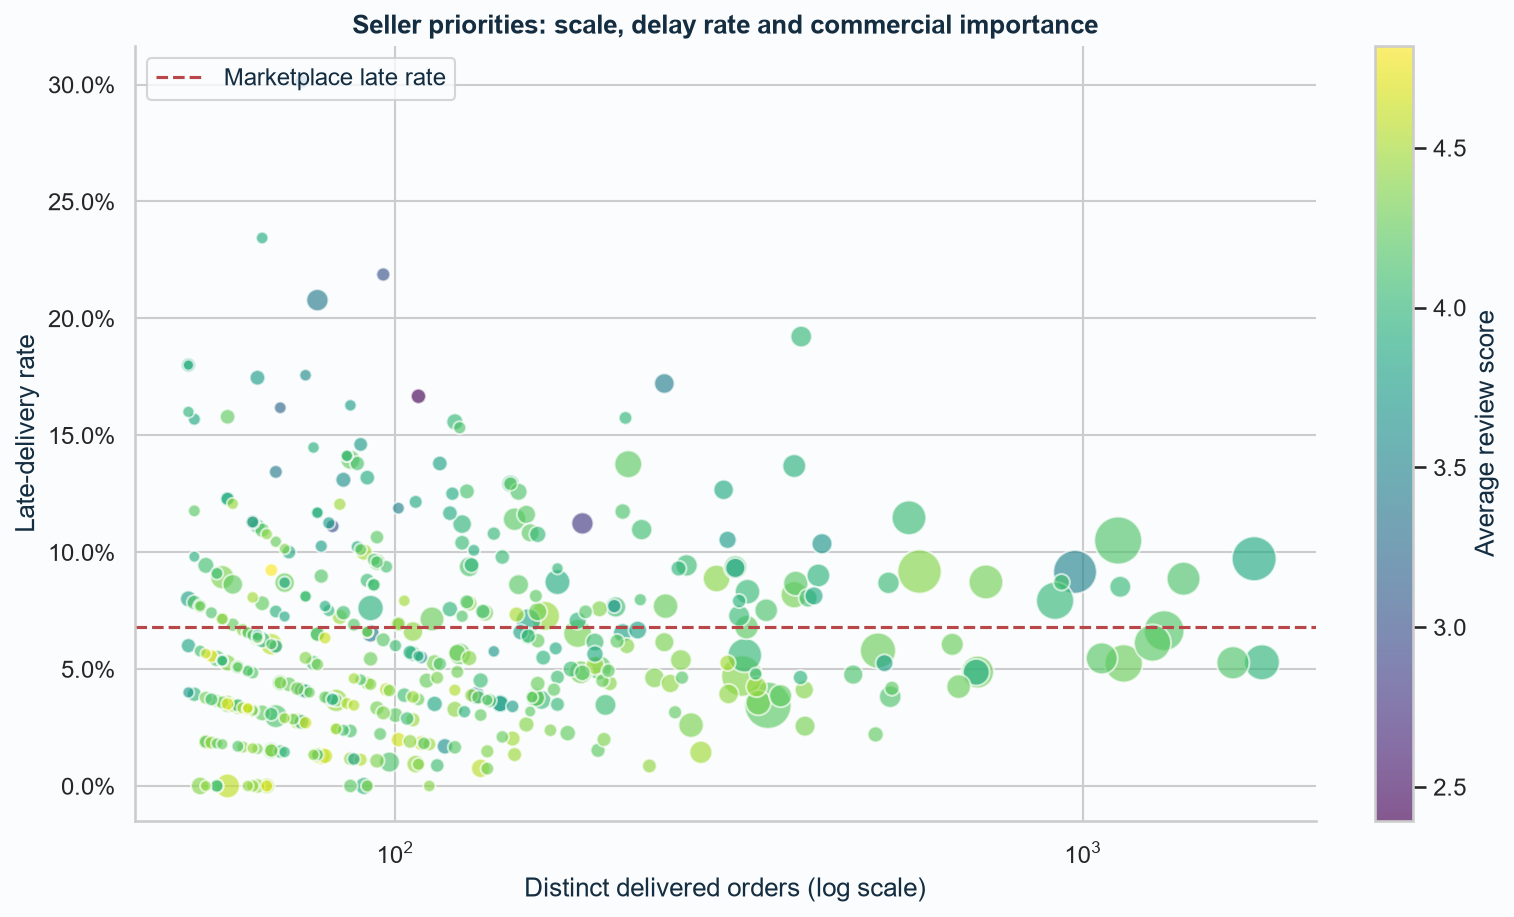

,seller_id,gmv,units,orders,customers,delivery_orders,late_orders,average_delivery_days,reviewed_orders,...,late_rate_baseline,excess_late_orders,gmv_on_late_orders,high_commercial_value,weak_experience,growth_rate,priority_group,priority_rank,cumulative_gmv_share
2,4a3ca9315b744ce9f8e9374361493884,"196,882.1200",1949,1772,1759,1770,172,14.4954,1753,...,0.0678,51.9190,"20,063.1900",True,True,-0.2270,Improvement priority,1.0000,0.0485
65,06a2c3af7b3aee5d69171b0e14f0ee87,"36,097.9800",402,389,385,385,74,17.7844,385,...,0.0678,47.8807,"6,564.2200",True,True,2.0684,Improvement priority,2.0000,0.3793
0,4869f7a5dfa277a7dca6462dcf3b52b2,"226,987.9300",1148,1124,1117,1124,118,15.0624,1116,...,0.0678,41.7452,"24,509.2000",True,True,-0.4023,Improvement priority,3.0000,0.0172
15,1f50f920176fa81dab994f9023523100,"106,655.7100",1926,1399,1383,1399,124,15.8093,1394,...,0.0678,29.0885,"8,250.3000",True,True,-0.4551,Improvement priority,4.0000,0.1846
40,8160255418d5aaa7dbdc9f4c64ebda44,"46,368.3900",424,380,378,380,52,16.2496,376,...,0.0678,26.2199,"6,924.6000",True,True,-0.3253,Improvement priority,5.0000,0.3016
13,7d13fca15225358621be4086e1eb0964,"112,436.1800",571,558,557,558,64,15.7316,555,...,0.0678,26.1440,"14,042.4400",True,True,-0.1408,Improvement priority,6.0000,0.1682
77,88460e8ebdecbfecb5f9601833981930,"31,320.4000",300,246,240,244,42,17.9032,245,...,0.0678,25.4465,"6,179.5500",True,True,-0.2951,Improvement priority,7.0000,0.4090
4,7c67e1448b00f6e969d365cea6b010ab,"186,570.0500",1355,973,962,972,89,22.3558,967,...,0.0678,23.0572,"16,506.1700",True,True,-0.5242,Improvement priority,8.0000,0.0771
62,ea8482cd71df3c1969d7b9473ff13abc,"36,696.7600",1188,1132,1119,1127,96,13.3499,1126,...,0.0678,19.5416,"2,993.7400",True,True,-0.4845,Improvement priority,9.0000,0.3711
387,e5a3438891c0bfdb9394643f95273d8e,"7,549.9600",247,216,209,216,34,15.6631,215,...,0.0678,19.3460,"1,143.6000",True,True,-1.0000,Improvement priority,10.0000,0.7294


,entity,minimum_orders,rate_eligible_entities,high_value_weak_experience_entities
0,categories,30,63,3
1,categories,50,59,3
2,categories,100,52,3
3,sellers,30,622,73
4,sellers,50,417,57
5,sellers,100,208,37
6,geography,30,27,3
7,geography,50,26,3
8,geography,100,24,3


**What the data shows:** The scorecard shows commercial exposure and excess late orders alongside sample size and confidence bounds.

**Business interpretation:** The highest raw delay count and the highest delay rate are different management signals.

**Recommended action:** Audit the leading eligible sellers and test targeted process changes with comparison groups.

**KPI to monitor:** Excess late orders, late rate, review rate and GMV; repeat rankings at 30/50/100 sample thresholds.

In [6]:
chart('seller_performance_matrix.png')
display(analytics['sellers'].query('rate_rank_eligible').sort_values('priority_rank').head(12))
display(analytics['priority_sensitivity'])
decision('The scorecard shows commercial exposure and excess late orders alongside sample size and confidence bounds.',
         'The highest raw delay count and the highest delay rate are different management signals.',
         'Audit the leading eligible sellers and test targeted process changes with comparison groups.',
         'Excess late orders, late rate, review rate and GMV; repeat rankings at 30/50/100 sample thresholds.')

## Geographic business performance
Use the destination state on each order. This is observed marketplace concentration, not addressable market size. Lower sales alone cannot establish an untapped opportunity.

In [7]:
display(analytics['geography'].head(15))
r=analytics['geography'].iloc[0]
decision(f"{r.customer_state} accounts for {r.gmv_share:.1%} of delivered GMV.",
         'Commercial concentration increases the importance of reliable service in this observed market.',
         'Compare delivery outcomes and seller/category mix in major destination states.',
         'State GMV share, delivery-eligible orders, late rate and review score.')

,customer_state,gmv,units,orders,customers,delivery_orders,late_orders,average_delivery_days,reviewed_orders,...,late_rate_baseline,excess_late_orders,gmv_on_late_orders,high_commercial_value,weak_experience,growth_rate,priority_group,priority_rank,cumulative_gmv_share
0,SP,"5,067,633.1600",46448,40501,39156,40428,1819,8.7664,40273,...,0.0678,0.0000,"269,356.5200",True,False,0.0100,Strong commercial performer,16.0000,0.3833
1,RJ,"1,759,651.1300",14143,12350,11917,12330,1495,15.3205,12211,...,0.0678,658.5035,"215,415.4600",True,True,-0.0624,Improvement priority,1.0000,0.5164
2,MG,"1,552,481.8300",12916,11354,11001,11327,519,12.0237,11285,...,0.0678,0.0000,"75,837.4900",True,False,-0.0953,Strong commercial performer,16.0000,0.6338
3,RS,"728,897.4700",6134,5345,5168,5327,325,15.3225,5327,...,0.0678,0.0000,"43,968.0300",True,False,-0.1223,Strong commercial performer,16.0000,0.6889
4,PR,"666,063.5100",5649,4923,4769,4912,199,12.0033,4900,...,0.0678,0.0000,"29,504.0500",True,False,-0.1692,Strong commercial performer,16.0000,0.7393
5,SC,"507,012.1300",4097,3546,3449,3534,291,14.9816,3519,...,0.0678,51.2450,"38,103.9500",True,True,-0.1186,Improvement priority,7.0000,0.7777
6,BA,"493,584.1400",3683,3256,3158,3252,395,19.3368,3229,...,0.0678,174.3766,"61,968.7500",True,True,0.1520,Improvement priority,2.0000,0.8150
7,DF,"296,498.4100",2355,2080,2019,2077,118,12.9784,2070,...,0.0678,0.0000,"13,862.1300",False,False,0.1213,Growth candidate,16.0000,0.8374
8,GO,"282,836.7000",2277,1957,1895,1951,128,15.6281,1946,...,0.0678,0.0000,"18,365.9800",False,False,0.0759,Growth candidate,16.0000,0.8588
9,ES,"268,643.4500",2225,1995,1928,1989,214,15.8074,1969,...,0.0678,79.0615,"34,907.6800",False,True,0.3222,Monitor,4.0000,0.8791


**What the data shows:** SP accounts for 38.3% of delivered GMV.

**Business interpretation:** Commercial concentration increases the importance of reliable service in this observed market.

**Recommended action:** Compare delivery outcomes and seller/category mix in major destination states.

**KPI to monitor:** State GMV share, delivery-eligible orders, late rate and review score.

## Payment behavior
Payment shares use payment-record value, never repeated across item rows. Orders with several payment types form a mixed group in order-value comparisons. Installment count is the maximum recorded on an order, not a sum across tender rows.

In [8]:
display(analytics['payment_types'])
display(analytics['payment_behavior'])
top=analytics['payment_types'].sort_values('payment_value',ascending=False).iloc[0]
decision(f"{top.payment_type} has {top.payment_value_share:.1%} of observed commercial payment value.",
         'Payment usage is descriptive and does not establish that a tender causes larger baskets.',
         'Investigate installment usability by order-value band before proposing a payment experiment.',
         'Payment coverage, tender share and AOV within comparable value bands.')

,payment_type,payment_value,payment_records,orders,payment_value_share
0,boleto,"2,769,932.5800",19191,19191,0.1796
1,credit_card,"12,101,094.8800",74586,74304,0.7846
2,debit_card,"208,421.1200",1486,1485,0.0135
3,voucher,"343,013.1900",5493,3679,0.0222


,payment_group,value_band,orders,aov,median_max_installments
0,boleto,"(-0.001, 50.0]",6784,31.3781,1.0000
1,boleto,"(100.0, 250.0]",5230,153.7220,1.0000
2,boleto,"(1000.0, inf]",141,"1,708.5102",1.0000
3,boleto,"(250.0, 500.0]",1111,339.6861,1.0000
4,boleto,"(50.0, 100.0]",5523,75.4497,1.0000
5,boleto,"(500.0, 1000.0]",402,691.4754,1.0000
6,credit_card,"(-0.001, 50.0]",20299,32.3039,1.0000
7,credit_card,"(100.0, 250.0]",22829,156.2198,3.0000
8,credit_card,"(1000.0, inf]",732,"1,595.0528",8.0000
9,credit_card,"(250.0, 500.0]",5622,341.8272,5.0000


**What the data shows:** credit_card has 78.5% of observed commercial payment value.

**Business interpretation:** Payment usage is descriptive and does not establish that a tender causes larger baskets.

**Recommended action:** Investigate installment usability by order-value band before proposing a payment experiment.

**KPI to monitor:** Payment coverage, tender share and AOV within comparable value bands.

## Post-purchase experience
Olist has no equivalent product-return records in this project. Examine deliveries and reviews instead. Review comparisons use the intersection of valid delivery and review populations.

,delivery_status,orders,average_review_score,low_review_rate
0,Late,6379,2.2704,0.6242
1,On time,89258,4.2906,0.0926


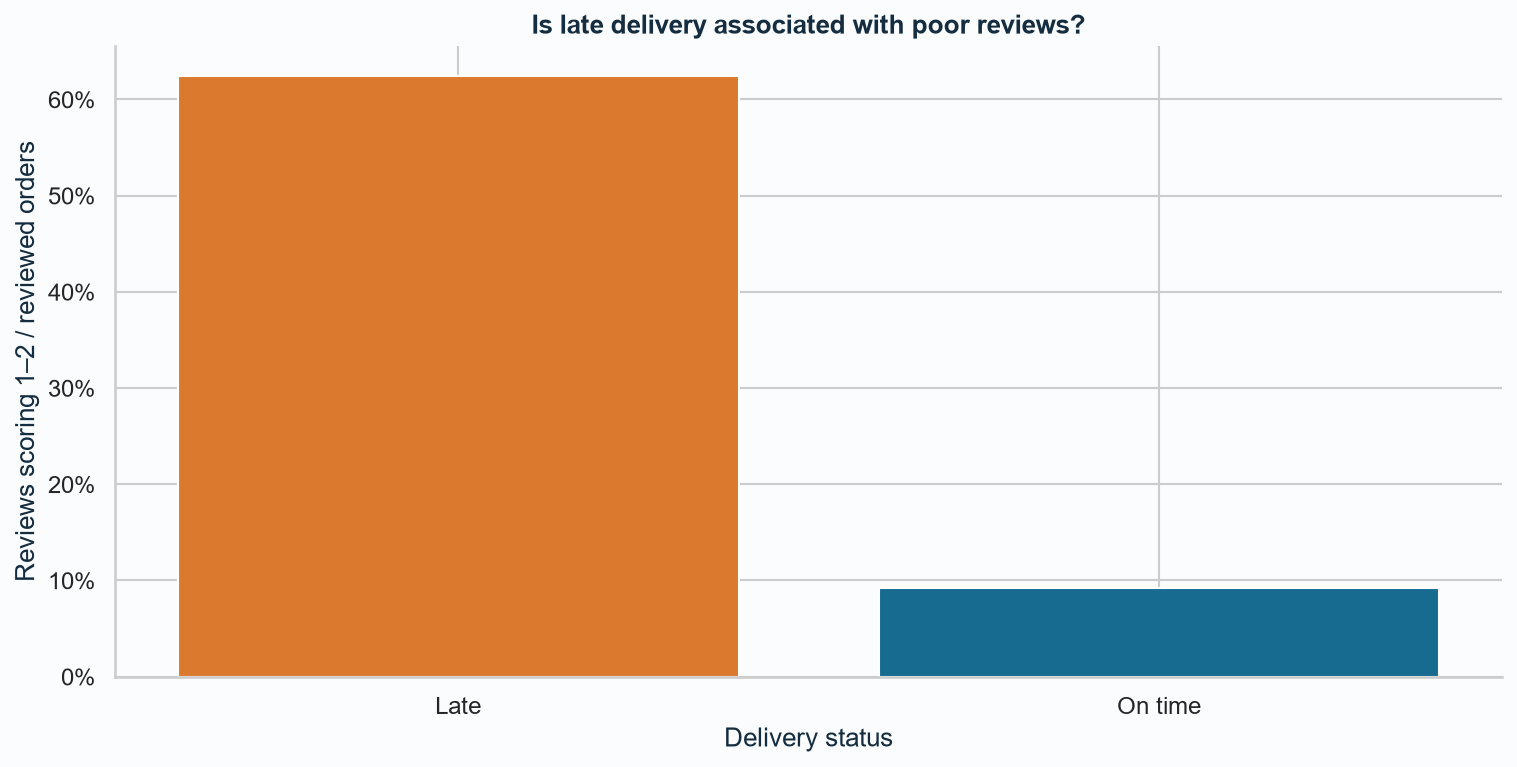

**What the data shows:** Low-review rates are 62.4% for late versus 9.3% for on-time orders.

**Business interpretation:** The association is material, but product, seller and customer differences may confound it.

**Recommended action:** Test proactive communication and fulfillment improvements rather than asserting causation.

**KPI to monitor:** Low-review rate and delivery timeliness in a matched or randomized evaluation.

In [9]:
display(analytics['delivery_reviews'])
chart('delivery_reviews.png')
d=analytics['delivery_reviews'].set_index('delivery_status')
decision(f"Low-review rates are {d.loc['Late','low_review_rate']:.1%} for late versus {d.loc['On time','low_review_rate']:.1%} for on-time orders.",
         'The association is material, but product, seller and customer differences may confound it.',
         'Test proactive communication and fulfillment improvements rather than asserting causation.',
         'Low-review rate and delivery timeliness in a matched or randomized evaluation.')

## Actual concentration rather than an assumed 80/20 rule

,entity,target_gmv_share,entities_required,total_entities,entity_share
0,customer,0.5000,14179,93358,0.1519
1,customer,0.8000,42009,93358,0.4500
2,category,0.5000,8,74,0.1081
3,category,0.8000,18,74,0.2432
4,seller,0.5000,127,2970,0.0428
5,seller,0.8000,533,2970,0.1795


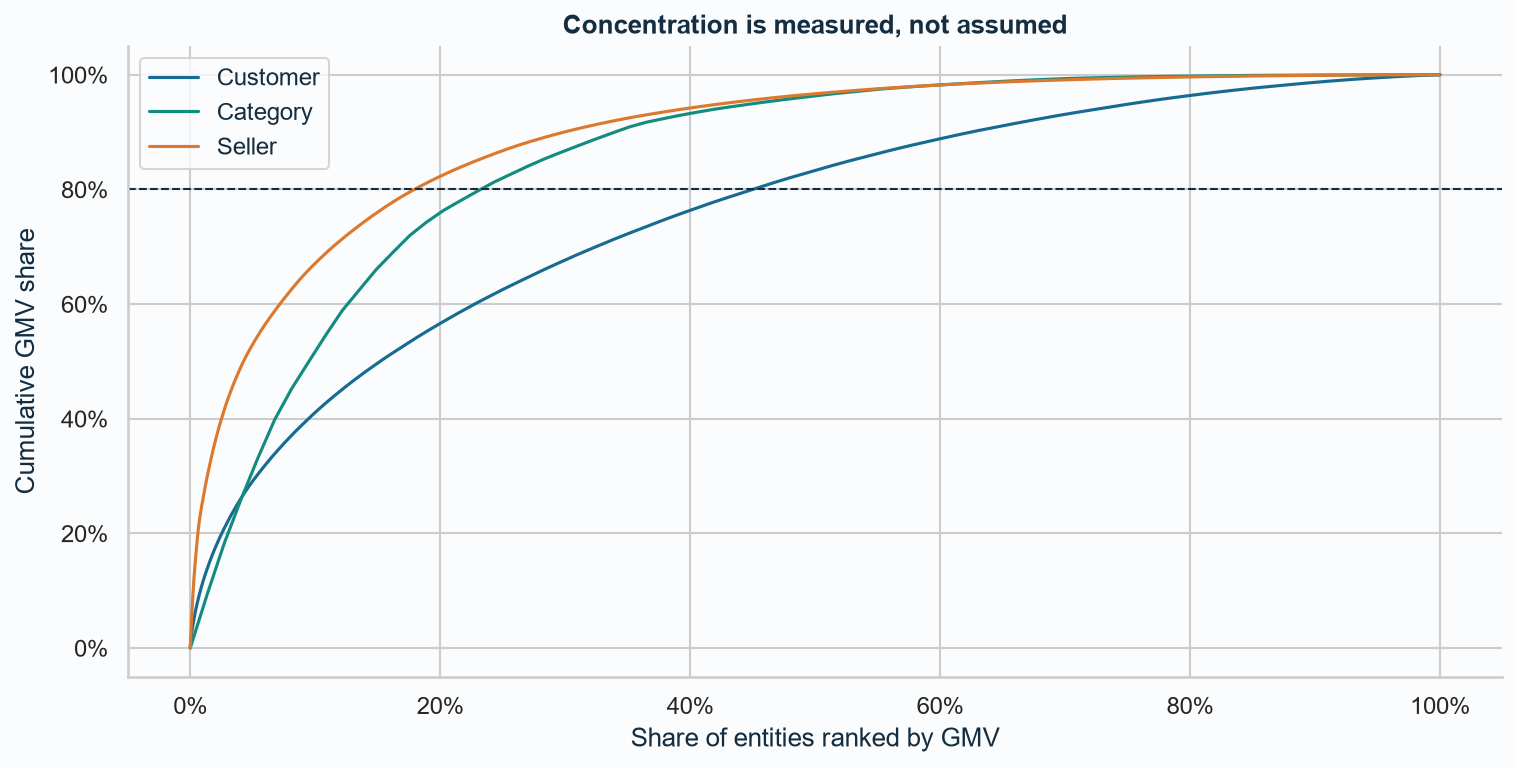

In [10]:
display(analytics['concentration_summary'])
chart('pareto.png')

## SQL analytics layer
SQLite queries implement CTEs, joins, conditional aggregation, ranks, cumulative windows and LAG. Independent outputs are reconciled to Python for executive, growth, customer, category, seller and cohort metrics. Monthly SQL uses active months; the Python calendar also explicitly fills empty months.

In [11]:
display(analytics['sql_reconciliation'])
assert analytics['sql_reconciliation'].passed.all()
decision('All listed SQL/Python comparisons pass within numerical tolerance.',
         'Definitions are portable across the analysis and BI backend.',
         'Keep reconciliation as a required step on every data refresh.',
         'Zero unexplained differences across validated KPI queries.')

,check,passed
0,SQL gmv,True
1,SQL orders,True
2,SQL customers,True
3,SQL aov,True
4,SQL repeat_customer_rate,True
5,SQL late_delivery_rate,True
6,SQL monthly gmv,True
7,SQL monthly orders,True
8,SQL monthly customers,True
9,SQL monthly aov,True


**What the data shows:** All listed SQL/Python comparisons pass within numerical tolerance.

**Business interpretation:** Definitions are portable across the analysis and BI backend.

**Recommended action:** Keep reconciliation as a required step on every data refresh.

**KPI to monitor:** Zero unexplained differences across validated KPI queries.